# Классификация отзывов WB по корневым категориям
**Модель:** `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`  
**Методы:** Логистическая регрессия · Центроидный классификатор · Сиамская сеть  
**v3:** три файла эмбеддингов + метод-специфичный поиск товаров

---
### Схема файлов и поиска

| Файл | Содержимое | Используется в поиске |
|---|---|---|
| `reviews_embeddings_minilm.h5` | Все отзывы (MiniLM, dim=384) | Обучение классификаторов |
| `products_raw_minilm.h5` | Все товары (MiniLM, порядок произвольный) | **Метод А** (LogReg) |
| `products_siamese_minilm.h5` | Все товары (через `siamese.encode()`) | **Метод В** (Siamese) |

**Метод Б (Центроиды):** файл на диске не нужен — центроиды в памяти.  
Запрос → ближайший центроид (= лучшая категория) → поиск товаров внутри неё из Файла 2.  
Единственный метод, **автоматически определяющий категорию** из запроса.

## 0. Установка зависимостей

In [8]:
!pip install -q sentence-transformers scikit-learn sqlalchemy psycopg2-binary pandas numpy matplotlib seaborn torch h5py tqdm

## 1. Импорты и глобальные настройки

In [1]:
import numpy as np
import pandas as pd
import random
import os
import time
import h5py
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sqlalchemy import create_engine
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

# ── Воспроизводимость ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f"SEED = {SEED}  |  torch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

SEED = 42  |  torch 2.10.0+cpu  |  CUDA: False


## 2. Подключение к PostgreSQL

In [2]:
DB_USER     = 'admin'
DB_PASSWORD = 'admin123'
DB_HOST     = 'localhost'
DB_PORT     = '5433'
DB_NAME     = 'wb_reviews'

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
print("Подключение к БД установлено.")

Подключение к БД установлено.


## 3. Загрузка эмбеддинг-модели

`paraphrase-multilingual-MiniLM-L12-v2` — лёгкая мультиязычная модель (117M параметров, dim=384).  
Работает значительно быстрее RuBERT (dim=768) и E5-large (dim=1024), что важно при большом корпусе товаров.  
Не требует префиксов — текст передаётся напрямую.

In [3]:
# MiniLM не требует специальных префиксов — тексты подаются как есть
MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
print(f"Загрузка модели {MODEL_NAME} ...")
model_st = SentenceTransformer(MODEL_NAME)
print(f"Модель загружена.  dim={model_st.get_sentence_embedding_dimension()}")

Загрузка модели sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена.  dim=384


## 4. Параметры и пути к файлам кеша

Все три кеш-файла определены здесь, чтобы менять пути в одном месте.  
Файлы названы с суффиксом `_minilm`, чтобы не конфликтовать с кешами других моделей.

In [4]:
CHUNK_SIZE   = 10_000
TOTAL_LIMIT  = 1_000_000

# ── Файл 1: эмбеддинги всех отзывов (используется для обучения классификаторов) ──
# MiniLM: dim=384, компактный кеш
CACHE_REVIEWS  = 'reviews_embeddings_minilm.h5'

# ── Файл 2: эмбеддинги всех товаров от MiniLM, порядок произвольный ──────────────
#    Используется при поиске методом А (LogReg):
#    запрос кодируется MiniLM и ищется в этом пространстве напрямую.
CACHE_PRODUCTS_RAW  = 'products_raw_minilm.h5'

# ── Файл 3: те же товары, прогнанные через siamese.encode() ──────────────────────
#    Используется при поиске методом В (Siamese):
#    запрос тоже проходит через siamese.encode() → оба в метрическом пространстве.
#    Файл создаётся ПОСЛЕ обучения сиамской сети (секция «Метод В»).
CACHE_PRODUCTS_SIAM = 'products_siamese_minilm.h5'

print("Пути к файлам кеша:")
print(f"  Файл 1 (отзывы):          {CACHE_REVIEWS}")
print(f"  Файл 2 (товары MiniLM):   {CACHE_PRODUCTS_RAW}")
print(f"  Файл 3 (товары Siamese):  {CACHE_PRODUCTS_SIAM}")

Пути к файлам кеша:
  Файл 1 (отзывы):          reviews_embeddings_minilm.h5
  Файл 2 (товары MiniLM):   products_raw_minilm.h5
  Файл 3 (товары Siamese):  products_siamese_minilm.h5


## 5. Файл 1 — Загрузка и кеширование эмбеддингов отзывов

Если `reviews_embeddings_minilm.h5` уже существует — загружаем из него (экономит время при повторных запусках).  
Иначе — читаем отзывы из БД чанками, векторизуем MiniLM, сохраняем.

In [5]:
if os.path.exists(CACHE_REVIEWS):
    print(f"[Файл 1] Кеш найден: {CACHE_REVIEWS} — загружаю...")
    with h5py.File(CACHE_REVIEWS, 'r') as f:
        X_all     = f['X'][:]                           # float32 (N, dim)
        y_all     = f['y_root'].asstr()[:] # корневые категории
        texts_all = f['texts'].asstr()[:] # исходные тексты
    print(f"[Файл 1] Загружено: {len(X_all)} отзывов  |  dim={X_all.shape[1]}")

else:
    print(f"[Файл 1] Кеш не найден — читаю из БД и векторизую...")

    sql_query = f"""
    SELECT r.review_text, p.subj_root_name
    FROM wb_reviews r
    INNER JOIN wb_products p ON r.nm_id = p.nm_id
    WHERE r.review_text IS NOT NULL AND r.review_text <> ''
    GROUP BY r.id, p.subj_root_name
    LIMIT {TOTAL_LIMIT}
    """

    X_vectors, y_root, raw_texts_all = [], [], []
    for chunk in pd.read_sql(sql_query, engine, chunksize=CHUNK_SIZE):
        texts = chunk['review_text'].tolist()
        # MiniLM: префиксы не нужны, batch_size=64 ускоряет — модель лёгкая
        embs  = model_st.encode(texts, batch_size=64, show_progress_bar=False)
        X_vectors.extend(embs.astype(np.float32))
        y_root.extend(chunk['subj_root_name'].tolist())
        raw_texts_all.extend(texts)
        print(f"  векторизовано: {len(X_vectors)} / {TOTAL_LIMIT}", end='\r')

    X_all     = np.array(X_vectors,   dtype=np.float32)
    y_all     = np.array(y_root)
    texts_all = np.array(raw_texts_all)

    print(f"\n[Файл 1] Векторизация завершена: {len(X_all)} отзывов  |  dim={X_all.shape[1]}")
    print(f"[Файл 1] Сохраняю в {CACHE_REVIEWS} ...")
    with h5py.File(CACHE_REVIEWS, 'w') as f:
        f.create_dataset('X',      data=X_all, compression='gzip')
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('y_root', data=np.asarray(y_all,     dtype=object), dtype=dt)
        f.create_dataset('texts',  data=np.asarray(texts_all, dtype=object), dtype=dt)
    print(f"[Файл 1] Сохранён: {CACHE_REVIEWS}")

[Файл 1] Кеш найден: reviews_embeddings_minilm.h5 — загружаю...
[Файл 1] Загружено: 1000000 отзывов  |  dim=384


## 6. Сводка категорий и выбор рабочего набора

In [6]:
cat_counts = pd.Series(y_all).value_counts().reset_index()
cat_counts.columns = ['Категория', 'Количество отзывов']
print("=" * 55)
print("СВОДКА: корневые категории в датасете")
print("=" * 55)
print(cat_counts.to_string(index=False))
print("=" * 55)
print(f"Итого категорий: {len(cat_counts)}  |  Всего отзывов: {len(y_all)}")

СВОДКА: корневые категории в датасете
                               Категория  Количество отзывов
                                  Одежда              386111
                                   Обувь              162724
                                 Красота               83179
                              Аксессуары               57354
                                   Белье               42780
                                 Игрушки               26259
                                     Дом               23488
               Книжная продукция и диски               19346
                      Посуда и инвентарь               18423
                       Спортивная одежда               17530
                      Товары для малышей               16582
                          Головные уборы               15597
                      Одежда для малышей               12493
                     Ювелирные украшения                9785
                    Хозяйственные товары       

In [7]:
# ── Выбор категорий ───────────────────────────────────────────────────────────
# ВАРИАНТ A: укажите категории вручную через запятую (оставьте пустым для Варианта Б)
MANUAL_CATEGORIES = "Одежда, Обувь, Красота, Посуда и инвентарь, Дом"   # пример: "Одежда, Обувь, Электроника"

# ВАРИАНТ Б: минимальное число отзывов для автоматического включения категории
MIN_REVIEWS = 500

if MANUAL_CATEGORIES.strip():
    selected = [c.strip() for c in MANUAL_CATEGORIES.split(',')]
    missing  = [c for c in selected if c not in cat_counts['Категория'].values]
    if missing:
        print(f"   Не найдены в данных: {missing}")
    selected = [c for c in selected if c in cat_counts['Категория'].values]
    print(f"\nВариант А — выбрано вручную ({len(selected)} кат.): {selected}")
else:
    auto_df  = cat_counts[cat_counts['Количество отзывов'] >= MIN_REVIEWS]
    selected = auto_df['Категория'].tolist()
    print(f"\nВариант Б — категории с >= {MIN_REVIEWS} отзывов ({len(selected)} шт.):")
    print(auto_df.to_string(index=False))

if not selected:
    raise ValueError("Нет подходящих категорий — измените параметры выбора.")

mask           = np.isin(y_all, selected)
X_filtered     = X_all[mask]
y_filtered     = y_all[mask]
texts_filtered = texts_all[mask]
print(f"\nПосле фильтрации: {len(X_filtered)} отзывов, {len(np.unique(y_filtered))} категорий.")


Вариант А — выбрано вручную (5 кат.): ['Одежда', 'Обувь', 'Красота', 'Посуда и инвентарь', 'Дом']

После фильтрации: 673925 отзывов, 5 категорий.


## 7. Балансировка классов

In [8]:
MAX_PER_CLASS   = 7000
MIN_PER_CLASS   = 3000
IMBALANCE_RATIO = 5.0

set_seed(SEED)
df_bal = pd.DataFrame({'text_idx': range(len(X_filtered)), 'root': y_filtered})

counts_before = df_bal['root'].value_counts()
ratio = counts_before.max() / counts_before.min()
if ratio > IMBALANCE_RATIO:
    print(f"   Дисбаланс классов обнаружен (max/min = {ratio:.1f}):")
    print(counts_before.to_string())
else:
    print(f"Дисбаланс в норме (max/min = {ratio:.1f}).")

# Шаг 1: догрузка малых классов из БД
small_classes    = counts_before[counts_before < MIN_PER_CLASS * 2].index.tolist()
enlarged_classes = []
if small_classes:
    print(f"\nДогрузка данных для малых классов: {small_classes}")
    placeholders = ', '.join([f"'{c}'" for c in small_classes])
    extra_sql = f"""
        SELECT r.review_text, p.subj_root_name
        FROM wb_reviews r
        INNER JOIN wb_products p ON r.nm_id = p.nm_id
        WHERE p.subj_root_name IN ({placeholders})
          AND r.review_text IS NOT NULL AND r.review_text <> ''
        GROUP BY r.id, p.subj_root_name
    """
    try:
        extra_df = pd.read_sql(extra_sql, engine)
        if len(extra_df) > 0:
            extra_emb      = model_st.encode(extra_df['review_text'].tolist(),
                                             batch_size=64, show_progress_bar=False).astype(np.float32)
            X_filtered     = np.vstack([X_filtered, extra_emb])
            y_filtered     = np.concatenate([y_filtered, extra_df['subj_root_name'].values])
            texts_filtered = np.concatenate([texts_filtered, extra_df['review_text'].values])
            df_bal         = pd.DataFrame({'text_idx': range(len(X_filtered)), 'root': y_filtered})
            enlarged_classes = small_classes
            print(f"  Увеличен размер классов: {enlarged_classes}")
    except Exception as e:
        print(f"Не удалось догрузить данные: {e}")

# Шаг 2: исключение слишком малых классов
counts_now      = df_bal['root'].value_counts()
too_small       = counts_now[counts_now < MIN_PER_CLASS].index.tolist()
removed_classes = []
if too_small:
    df_bal          = df_bal[~df_bal['root'].isin(too_small)]
    removed_classes = too_small
    print(f"  Удалены категории (< {MIN_PER_CLASS} отзывов): {removed_classes}")

# Шаг 3: обрезка слишком больших классов до MAX_PER_CLASS
balanced_indices = []
for cat, grp in df_bal.groupby('root'):
    idx = grp['text_idx'].values
    if len(idx) > MAX_PER_CLASS:
        idx = np.random.choice(idx, MAX_PER_CLASS, replace=False)
    balanced_indices.extend(idx)

balanced_indices = np.array(balanced_indices)
X_bal     = X_filtered[balanced_indices]
y_bal     = y_filtered[balanced_indices]
texts_bal = texts_filtered[balanced_indices]

final_counts = pd.Series(y_bal).value_counts()
print("\nРаспределение классов после балансировки:")
print(final_counts.to_string())
print(f"\nИтого: {len(X_bal)} отзывов, {len(final_counts)} категорий.")
if removed_classes:  print(f"Удалены категории: {removed_classes}")
if enlarged_classes: print(f"Увеличен размер классов: {enlarged_classes}")

   Дисбаланс классов обнаружен (max/min = 21.0):
root
Одежда                386111
Обувь                 162724
Красота                83179
Дом                    23488
Посуда и инвентарь     18423

Распределение классов после балансировки:
Дом                   7000
Красота               7000
Обувь                 7000
Одежда                7000
Посуда и инвентарь    7000

Итого: 35000 отзывов, 5 категорий.


## 8. Разбивка на train / val / test и кодирование меток

In [9]:
set_seed(SEED)

# 70% train, 15% val, 15% test — стратифицировано по категории
X_train, X_temp, y_train, y_temp, texts_train, texts_temp = train_test_split(
    X_bal, y_bal, texts_bal, test_size=0.30, random_state=SEED, stratify=y_bal
)
X_val, X_test, y_val, y_test, texts_val, texts_test = train_test_split(
    X_temp, y_temp, texts_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Гарантия: нет unseen-категорий в val/test
train_cats  = set(y_train)
unseen_val  = set(y_val)  - train_cats
unseen_test = set(y_test) - train_cats
if unseen_val or unseen_test:
    print(f"   Unseen в val: {unseen_val} | в test: {unseen_test} — удаляем.")
    m_v = np.isin(y_val,  list(train_cats))
    m_t = np.isin(y_test, list(train_cats))
    X_val,   y_val,   texts_val   = X_val[m_v],   y_val[m_v],   texts_val[m_v]
    X_test,  y_test,  texts_test  = X_test[m_t],  y_test[m_t],  texts_test[m_t]
    assert len(X_val) > 0 and len(X_test) > 0
else:
    print("   Все категории в val/test присутствуют в train.")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

CLASS_NAMES = le.classes_.tolist()
print(f"\nTrain: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")
print(f"Классы ({len(CLASS_NAMES)}): {CLASS_NAMES}")

   Все категории в val/test присутствуют в train.

Train: 24500  |  Val: 5250  |  Test: 5250
Классы (5): ['Дом', 'Красота', 'Обувь', 'Одежда', 'Посуда и инвентарь']


## 9. Сохранение выборок

In [10]:
def save_split_hdf5(path, X, y_enc, y_str, texts, class_names):
    with h5py.File(path, 'w') as f:
        f.create_dataset('X',       data=X, compression='gzip')
        f.create_dataset('y_enc',   data=y_enc)
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('y_str',   data=np.asarray(y_str,       dtype=object), dtype=dt)
        f.create_dataset('texts',   data=np.asarray(texts,       dtype=object), dtype=dt)
        f.create_dataset('classes', data=np.asarray(class_names, dtype=object), dtype=dt)
    print(f"  Сохранено: {path}  ({len(X)} записей)")

print("Сохранение выборок...")
save_split_hdf5('train_split_minilm.h5', X_train, y_train_enc, y_train, texts_train, CLASS_NAMES)
save_split_hdf5('val_split_minilm.h5',   X_val,   y_val_enc,   y_val,   texts_val,   CLASS_NAMES)
save_split_hdf5('test_split_minilm.h5',  X_test,  y_test_enc,  y_test,  texts_test,  CLASS_NAMES)

Сохранение выборок...
  Сохранено: train_split_minilm.h5  (24500 записей)
  Сохранено: val_split_minilm.h5  (5250 записей)
  Сохранено: test_split_minilm.h5  (5250 записей)


## 10. Файл 2 — Загрузка и кеширование эмбеддингов товаров (MiniLM)

Загружаем все товары из `wb_products` со средним рейтингом из `wb_reviews`.  
Текст для эмбеддинга = `imt_name + '. ' + description`.  

**Используется методами А и Б:**  
оба работают в пространстве MiniLM — один и тот же индекс подходит для обоих.  
MiniLM при dim=384 занимает вдвое меньше памяти, чем RuBERT (dim=768), и вдвое меньше, чем E5-large (dim=1024).

In [11]:
if os.path.exists(CACHE_PRODUCTS_RAW):
    print(f"Найден кеш товаров: {CACHE_PRODUCTS_RAW}  — загружаю...")
    with h5py.File(CACHE_PRODUCTS_RAW, 'r') as f:
        prod_X = f['X'][:]
        prod_nm_ids = f['nm_ids'][:]
        prod_categories_raw = f['categories'][:]   # загружаем как есть (байты)
        prod_ratings = f['ratings'][:]
        prod_names_raw = f['names'][:]             # байты
        prod_descs_raw = f['descriptions'][:]      # байты

    # Функция для декодирования байтов в строки UTF‑8
    def decode_bytes(arr):
        if len(arr) > 0 and isinstance(arr[0], bytes):
            return np.array([x.decode('utf-8') for x in arr], dtype=object)
        return arr

    prod_categories = decode_bytes(prod_categories_raw)
    prod_names = decode_bytes(prod_names_raw)
    prod_descs = decode_bytes(prod_descs_raw)

    print(f"Загружено товаров из кеша: {len(prod_X)}")

else:
    print(f"[Файл 2] Кеш не найден — загружаю товары из БД...")

    products_sql = """
    SELECT
        p.nm_id,
        p.imt_name,
        p.subj_root_name,
        p.description,
        ROUND(AVG(r.product_valuation), 2) AS avg_rating
    FROM wb_products p
    INNER JOIN wb_reviews r ON p.nm_id = r.nm_id
    WHERE p.description IS NOT NULL
      AND p.description <> ''
      AND p.subj_root_name IS NOT NULL
    GROUP BY p.nm_id, p.imt_name, p.subj_root_name, p.description
    """
    products_df = pd.read_sql(products_sql, engine)
    products_df['description'] = products_df['description'].fillna('').astype(str)
    products_df['imt_name']    = products_df['imt_name'].fillna('').astype(str)

    # Текст для эмбеддинга: название + описание (без префиксов — MiniLM не требует)
    prod_texts = (products_df['imt_name'] + '. ' + products_df['description']).tolist()

    print(f"[Файл 2] Загружено {len(products_df)} товаров — векторизую...")
    # batch_size=64 — MiniLM быстрый, можно увеличить если хватает памяти GPU
    prod_X = model_st.encode(prod_texts, batch_size=64, show_progress_bar=True).astype(np.float32)

    prod_nm_ids     = products_df['nm_id'].values
    prod_categories = products_df['subj_root_name'].values
    prod_ratings    = products_df['avg_rating'].fillna(0).astype(np.float32).values
    prod_names      = products_df['imt_name'].values
    prod_descs      = products_df['description'].values

    print(f"[Файл 2] Сохраняю в {CACHE_PRODUCTS_RAW} ...")
    with h5py.File(CACHE_PRODUCTS_RAW, 'w') as f:
        f.create_dataset('X',            data=prod_X, compression='gzip')
        f.create_dataset('nm_ids',       data=prod_nm_ids)
        f.create_dataset('ratings',      data=prod_ratings)
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('categories',   data=np.asarray(prod_categories, dtype=object), dtype=dt)
        f.create_dataset('names',        data=np.asarray(prod_names,      dtype=object), dtype=dt)
        f.create_dataset('descriptions', data=np.asarray(prod_descs,      dtype=object), dtype=dt)
    print(f"[Файл 2] Сохранён: {CACHE_PRODUCTS_RAW}")

print(f"\n[Файл 2] Индекс готов: {prod_X.shape}  (товаров × dim)")

Найден кеш товаров: products_raw_minilm.h5  — загружаю...
Загружено товаров из кеша: 785591

[Файл 2] Индекс готов: (785591, 384)  (товаров × dim)


## 11. Вспомогательные функции

In [12]:
# ── Матрица ошибок ─────────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names) - 1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Предсказано', fontsize=12)
    ax.set_ylabel('Истинное',    fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ── Случайные примеры предсказаний ────────────────────────────────────────────
def show_random_predictions(y_true_str, y_pred_enc, le, raw_texts, n=10):
    """# | Текст отзыва | Истинная кат. | Предсказание | ✓?"""
    set_seed(SEED)
    idx        = np.random.choice(len(y_true_str), min(n, len(y_true_str)), replace=False)
    y_pred_str = le.inverse_transform(y_pred_enc)
    TEXT_W, CAT_W = 45, 28
    print(f"{'#':<3} {'Текст отзыва':<{TEXT_W}} {'Истинная кат.':<{CAT_W}} {'Предсказание':<{CAT_W}} {'✓?'}")
    print("-" * (3 + 1 + TEXT_W + 1 + CAT_W + 1 + CAT_W + 1 + 3))
    for i, pos in enumerate(idx):
        snippet  = str(raw_texts[pos])[:TEXT_W].replace('\n', ' ')
        if len(str(raw_texts[pos])) > TEXT_W:
            snippet = snippet[:-1] + '…'
        true_lbl = y_true_str[pos]
        pred_lbl = y_pred_str[pos]
        ok       = "yes" if true_lbl == pred_lbl else "no"
        print(f"{i+1:<3} {snippet:<{TEXT_W}} {true_lbl:<{CAT_W}} {pred_lbl:<{CAT_W}} {ok}")


# ── F1-мера ───────────────────────────────────────────────────────────────────
def evaluate_f1(y_true_enc, y_pred_enc, average='weighted'):
    return f1_score(y_true_enc, y_pred_enc, average=average)


# ── Поиск top-k ближайших товаров ──────────────────────────────────────────────
def search_products(query_emb: np.ndarray,
                    category_filter: str,
                    index_X: np.ndarray,
                    nm_ids, categories, ratings, names, descs,
                    top_k: int = 10):
    """
    Ищет top_k товаров ближайших к query_emb по косинусному сходству.

    Параметры
    ---------
    query_emb       : вектор запроса (1-D), уже в нужном пространстве
    category_filter : название категории или 'все'
    index_X         : матрица товарных эмбеддингов (N, dim)

    Возвращает
    ----------
    (DataFrame с результатами, время_поиска_в_секундах)
    Время измеряется только для cosine_similarity + argsort,
    без учёта кодирования запроса моделью.
    """
    if category_filter.strip().lower() == 'все':
        idx_pool = np.arange(len(index_X))
    else:
        idx_pool = np.where(categories == category_filter)[0]

    if len(idx_pool) == 0:
        return pd.DataFrame(), 0.0

    t0      = time.perf_counter()
    sims    = cosine_similarity(query_emb.reshape(1, -1), index_X[idx_pool])[0]
    top     = np.argsort(sims)[::-1][:top_k]
    elapsed = time.perf_counter() - t0

    real_idx = idx_pool[top]
    results  = pd.DataFrame({
        'Артикул (nm_id)': nm_ids[real_idx],
        'Название':        names[real_idx],
        'Рейтинг':         ratings[real_idx],
        'Сходство':        sims[top].round(4),
        'Описание':        descs[real_idx],
    })
    return results, elapsed


# ── Красивый вывод результатов ─────────────────────────────────────────────────
def print_search_results(results: pd.DataFrame, elapsed: float, category_used: str = ''):
    cat_info = f"  Категория поиска: {category_used}" if category_used else ''
    print(f"\n  Время поиска по эмбеддингам: {elapsed*1000:.1f} мс"
          f"  |  Найдено: {len(results)} товаров{cat_info}")
    print("  " + "─" * 90)
    for rank, (_, row) in enumerate(results.iterrows(), 1):
        desc_snippet = str(row['Описание'])[:120].replace('\n', ' ')
        if len(str(row['Описание'])) > 120:
            desc_snippet += '…'
        print(f"  {rank:>2}. [{row['Артикул (nm_id)']}] {row['Название']}")
        print(f"      Рейтинг: {row['Рейтинг']:.2f} ★  |  Сходство: {row['Сходство']:.4f}")
        print(f"      {desc_snippet}")
        print()


# ── Сохранение лога поиска ─────────────────────────────────────────────────────
def save_search_log(log: list, path: str):
    if not log:
        return
    with h5py.File(path, 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('queries',    data=np.asarray([d['query']    for d in log], dtype=object), dtype=dt)
        f.create_dataset('categories', data=np.asarray([d['category'] for d in log], dtype=object), dtype=dt)
        f.create_dataset('elapsed_ms', data=np.array([d['elapsed_ms'] for d in log]))
    print(f"  Лог поиска сохранён: {path}  ({len(log)} запросов)")


print("Вспомогательные функции определены.")

Вспомогательные функции определены.


---
## Метод А: Логистическая регрессия

**Классификация:** эмбеддинги отзывов (MiniLM, dim=384) → признаки для LR.  
**Поиск:** запрос кодируется тем же MiniLM → поиск в **Файле 2** (`products_raw_minilm.h5`).  
Пространства запроса и товаров совпадают — прямое косинусное сравнение.

In [13]:
set_seed(SEED)

print("[A] Обучение логистической регрессии...")
clf_lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED)
clf_lr.fit(X_train, y_train_enc)

lr_val_pred  = clf_lr.predict(X_val)
lr_test_pred = clf_lr.predict(X_test)

lr_f1_val  = evaluate_f1(y_val_enc,  lr_val_pred)
lr_f1_test = evaluate_f1(y_test_enc, lr_test_pred)

print(f"F1 (weighted) на val:  {lr_f1_val:.4f}")
print(f"F1 (weighted) на test: {lr_f1_test:.4f}")

[A] Обучение логистической регрессии...
F1 (weighted) на val:  0.8337
F1 (weighted) на test: 0.8353


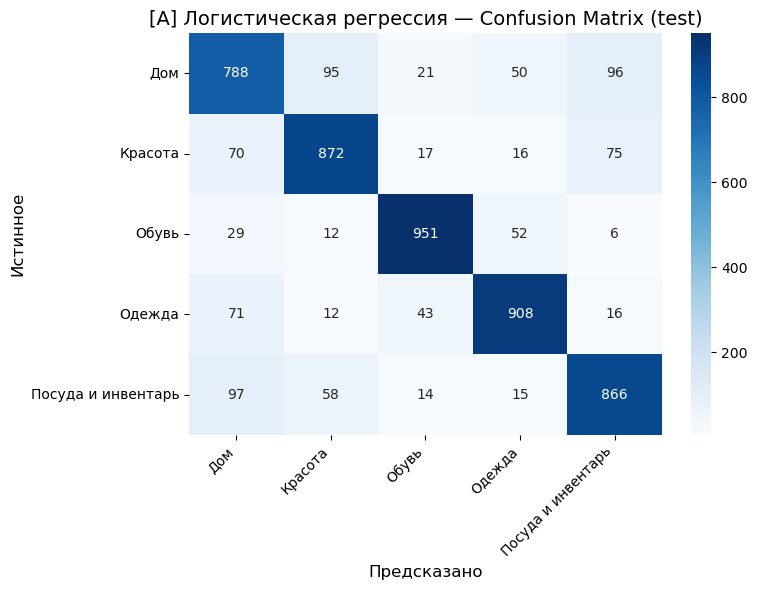

In [14]:
plot_confusion_matrix(y_test_enc, lr_test_pred, CLASS_NAMES,
                      title="[A] Логистическая регрессия — Confusion Matrix (test)")

In [15]:
print("\n[A] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, lr_test_pred, le, texts_test, n=10)


[A] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Лоферы очень красивые и качественно сделаны,… Обувь                        Обувь                        yes
2   Отличное платье, трикотаж мягкий, не просвеч… Одежда                       Одежда                       yes
3   Крем супер, круглогодично пользуюсь только и… Красота                      Красота                      yes
4   Пришёл целый, это главное.Брал для офиса,кол… Дом                          Дом                          yes
5   У дочери кудрявые волосы, после шампуня было… Красота                      Красота                      yes
6   Это не спрей. Внутри густая кремообразная ма… Красота                      Красота                      yes
7   Отличные сапоги, мне и нужны были не сильно … Обувь  

### Диалог классификации — Метод А

In [16]:
dialog_log_lr = []

print("=" * 60)
print("[A] Диалог: классификация текста (LogReg + MiniLM)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb      = model_st.encode([user_input])  # без префиксов
    pred_enc = clf_lr.predict(emb)[0]
    pred_lbl = le.inverse_transform([pred_enc])[0]
    prob     = clf_lr.predict_proba(emb)[0].max()
    print(f"  → Категория: {pred_lbl}  (уверенность: {prob:.2%})\n")
    dialog_log_lr.append({'text': user_input, 'predicted': pred_lbl, 'prob': float(prob)})

if dialog_log_lr:
    with h5py.File('dialog_logreg_minilm.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',       data=np.asarray([d['text']      for d in dialog_log_lr], dtype=object), dtype=dt)
        f.create_dataset('predictions', data=np.asarray([d['predicted'] for d in dialog_log_lr], dtype=object), dtype=dt)
        f.create_dataset('probs',       data=np.array([d['prob']        for d in dialog_log_lr]))
    print(f"Диалог сохранён: dialog_logreg_minilm.h5  ({len(dialog_log_lr)} запросов)")

[A] Диалог: классификация текста (LogReg + MiniLM)
Введите 'стоп' для выхода.
Доступные категории: ['Дом', 'Красота', 'Обувь', 'Одежда', 'Посуда и инвентарь']


Текст отзыва:  очень красивое платье до колен, приятная ткань


  → Категория: Одежда  (уверенность: 99.99%)



Текст отзыва:  тарелки отличные, отдельно хотела бы выделить рисунок. стеклянные и большие, очень нравится


  → Категория: Посуда и инвентарь  (уверенность: 99.46%)



Текст отзыва:  exit


Диалог сохранён: dialog_logreg_minilm.h5  (2 запросов)


### Поиск товаров — Метод А (LogReg)

**Индекс:** `products_raw_minilm.h5` (Файл 2) — MiniLM-эмбеддинги товаров.  
**Запрос:** кодируется тем же MiniLM → прямое косинусное сравнение с индексом.  
**Категория:** задаётся вручную или `все`.

In [17]:
search_log_lr  = []
categories_str = ', '.join(CLASS_NAMES)

print("=" * 70)
print("[A] Поиск товаров по запросу  (индекс: products_raw_minilm.h5)")
print(f"Доступные категории: {categories_str}")
print("Введите 'стоп' в любом поле для выхода.")
print("=" * 70)

while True:
    query = input("\nЗапрос товара: ").strip()
    if query.lower() in ('стоп', 'stop', 'exit', 'quit', ''):
        break

    print(f"  Доступные категории: {categories_str}")
    print("  (или введите 'все' для поиска по всем категориям)")
    cat_input = input("  Категория: ").strip()
    if cat_input.lower() in ('стоп', 'stop', 'exit', 'quit'):
        break
    if cat_input.lower() != 'все' and cat_input not in CLASS_NAMES:
        print(f"  Категория '{cat_input}' не найдена. Доступны: {categories_str}")
        continue

    # Кодируем запрос MiniLM — то же пространство, что и товары в Файле 2
    query_emb = model_st.encode([query]).astype(np.float32)[0]

    results, elapsed = search_products(
        query_emb, cat_input,
        prod_X,  # Файл 2: MiniLM-эмбеддинги товаров
        prod_nm_ids, prod_categories, prod_ratings, prod_names, prod_descs
    )
    if results.empty:
        print(f"  Нет товаров в категории '{cat_input}'.")
        continue

    print_search_results(results, elapsed, cat_input)
    search_log_lr.append({'query': query, 'category': cat_input, 'elapsed_ms': elapsed * 1000})

save_search_log(search_log_lr, 'search_log_logreg_minilm.h5')

[A] Поиск товаров по запросу  (индекс: products_raw_minilm.h5)
Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
Введите 'стоп' в любом поле для выхода.



Запрос товара:  платье до колен, приятная ткань


  Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
  (или введите 'все' для поиска по всем категориям)


  Категория:  все



  Время поиска по эмбеддингам: 1954.4 мс  |  Найдено: 10 товаров  Категория поиска: все
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [6507972] Платье
      Рейтинг: 2.00 ★  |  Сходство: 0.9104
      Стильное удобное вязаное платье до колена, изготовленно из качественной мягкой пряжи. Рост модели на фото 180 см.

   2. [4067257] Платье
      Рейтинг: 4.00 ★  |  Сходство: 0.9020
      Хлопковое платье с V-образным вырезом длиной до колена. Элегантный растительный принт.

   3. [6578932] Платье
      Рейтинг: 4.00 ★  |  Сходство: 0.8996
      Силуэтное платье с разрезом на бедре.

   4. [6578931] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.8996
      Силуэтное платье с разрезом на бедре.

   5. [4151334] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.8986
      платье, выполненное из принтованного штапеля, на подкладке.

   6. [8414633] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.8976
      Офисное платье из моделирующей фигуру ткани,

...

  Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
  (или введите 'все' для поиска по всем категориям)


  Категория:  Одежда



  Время поиска по эмбеддингам: 395.6 мс  |  Найдено: 10 товаров  Категория поиска: Одежда
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [6507972] Платье
      Рейтинг: 2.00 ★  |  Сходство: 0.9104
      Стильное удобное вязаное платье до колена, изготовленно из качественной мягкой пряжи. Рост модели на фото 180 см.

   2. [4067257] Платье
      Рейтинг: 4.00 ★  |  Сходство: 0.9020
      Хлопковое платье с V-образным вырезом длиной до колена. Элегантный растительный принт.

   3. [6578931] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.8996
      Силуэтное платье с разрезом на бедре.

   4. [6578932] Платье
      Рейтинг: 4.00 ★  |  Сходство: 0.8996
      Силуэтное платье с разрезом на бедре.

   5. [4151334] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.8986
      платье, выполненное из принтованного штапеля, на подкладке.

   6. [8414636] Платье
      Рейтинг: 4.67 ★  |  Сходство: 0.8976
      Офисное платье из моделирующей фигуру ткан


Запрос товара:  стоп


  Лог поиска сохранён: search_log_logreg_minilm.h5  (2 запросов)


---
## Метод Б: Центроидный классификатор

**Классификация:** ближайший центроид по cosine similarity.  
**Поиск:** двухэтапный, использует **Файл 2** (`products_raw_minilm.h5`):  
1. Запрос → сравнение с `centroid_matrix` → **автоматически** определяется лучшая категория.  
2. Внутри найденной категории — cosine search по товарным эмбеддингам.  

Категория не запрашивается у пользователя — центроид определяет её сам.

In [18]:
# Центроид класса = среднее эмбеддингов всех его обучающих отзывов
centroids = {}
for cls_int in np.unique(y_train_enc):
    mask = y_train_enc == cls_int
    centroids[cls_int] = X_train[mask].mean(axis=0)

# centroid_matrix[i] — эталонный вектор i-го класса
centroid_matrix = np.array([centroids[i] for i in sorted(centroids)], dtype=np.float32)
print(f"[Б] Центроиды вычислены: {centroid_matrix.shape}")

def centroid_predict(X, centroid_matrix):
    sims = cosine_similarity(X, centroid_matrix)
    return np.argmax(sims, axis=1)

cent_val_pred  = centroid_predict(X_val,  centroid_matrix)
cent_test_pred = centroid_predict(X_test, centroid_matrix)

cent_f1_val  = evaluate_f1(y_val_enc,  cent_val_pred)
cent_f1_test = evaluate_f1(y_test_enc, cent_test_pred)
print(f"F1 (weighted) на val:  {cent_f1_val:.4f}")
print(f"F1 (weighted) на test: {cent_f1_test:.4f}")

[Б] Центроиды вычислены: (5, 384)
F1 (weighted) на val:  0.7252
F1 (weighted) на test: 0.7220


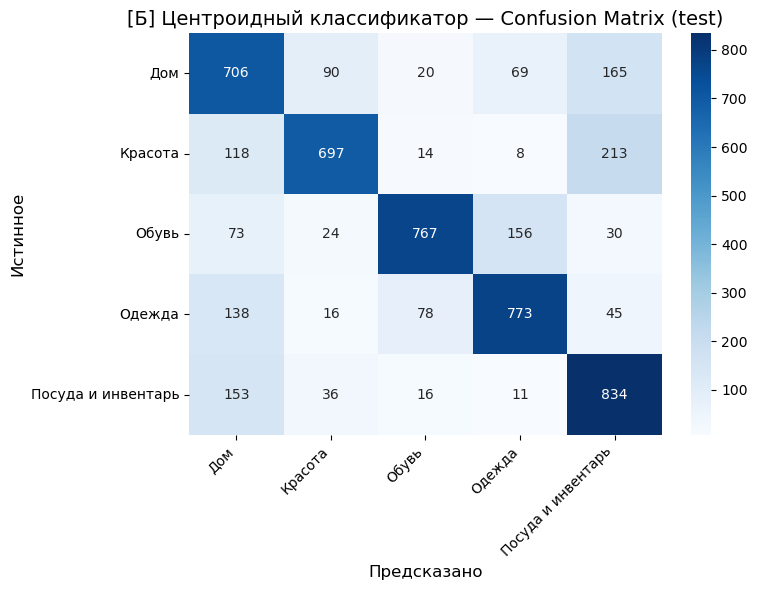

In [19]:
plot_confusion_matrix(y_test_enc, cent_test_pred, CLASS_NAMES,
                      title="[Б] Центроидный классификатор — Confusion Matrix (test)")

In [20]:
print("\n[Б] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, cent_test_pred, le, texts_test, n=10)


[Б] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Лоферы очень красивые и качественно сделаны,… Обувь                        Обувь                        yes
2   Отличное платье, трикотаж мягкий, не просвеч… Одежда                       Одежда                       yes
3   Крем супер, круглогодично пользуюсь только и… Красота                      Красота                      yes
4   Пришёл целый, это главное.Брал для офиса,кол… Дом                          Дом                          yes
5   У дочери кудрявые волосы, после шампуня было… Красота                      Красота                      yes
6   Это не спрей. Внутри густая кремообразная ма… Красота                      Посуда и инвентарь           no
7   Отличные сапоги, мне и нужны были не сильно … Обувь   

### Диалог классификации — Метод Б

In [21]:
dialog_log_cent = []

print("=" * 60)
print("[Б] Диалог: классификация текста (Центроиды + MiniLM)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb      = model_st.encode([user_input]).astype(np.float32)
    sims     = cosine_similarity(emb, centroid_matrix)[0]
    pred_enc = int(np.argmax(sims))
    pred_lbl = le.inverse_transform([pred_enc])[0]
    conf     = float(sims[pred_enc])
    print(f"  → Категория: {pred_lbl}  (cosine sim: {conf:.4f})\n")
    dialog_log_cent.append({'text': user_input, 'predicted': pred_lbl, 'similarity': conf})

if dialog_log_cent:
    with h5py.File('dialog_centroid_minilm.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',        data=np.asarray([d['text']       for d in dialog_log_cent], dtype=object), dtype=dt)
        f.create_dataset('predictions',  data=np.asarray([d['predicted']  for d in dialog_log_cent], dtype=object), dtype=dt)
        f.create_dataset('similarities', data=np.array([d['similarity']   for d in dialog_log_cent]))
    print(f"Диалог сохранён: dialog_centroid_minilm.h5  ({len(dialog_log_cent)} запросов)")

[Б] Диалог: классификация текста (Центроиды + MiniLM)
Введите 'стоп' для выхода.
Доступные категории: ['Дом', 'Красота', 'Обувь', 'Одежда', 'Посуда и инвентарь']


Текст отзыва:  платье до колен, приятная ткань


  → Категория: Одежда  (cosine sim: 0.6385)



Текст отзыва:  стоп


Диалог сохранён: dialog_centroid_minilm.h5  (1 запросов)


### Поиск товаров — Метод Б (Центроиды)

**Индекс:** `products_raw_minilm.h5` (Файл 2).  
**Шаг 1:** запрос → cosine с centroid_matrix → автовыбор категории.  
**Шаг 2:** поиск топ-10 товаров внутри найденной категории.

In [22]:
search_log_cent = []

print("=" * 70)
print("[Б] Поиск товаров по запросу  (индекс: products_raw_minilm.h5)")
print("Категория определяется автоматически по ближайшему центроиду.")
print("Введите 'стоп' для выхода.")
print("=" * 70)

while True:
    query = input("\nЗапрос товара: ").strip()
    if query.lower() in ('стоп', 'stop', 'exit', 'quit', ''):
        break

    # Кодируем запрос — MiniLM (то же пространство, что у центроидов и товаров)
    query_emb = model_st.encode([query]).astype(np.float32)[0]

    # Шаг 1: ближайший центроид → автовыбор категории
    cat_sims    = cosine_similarity(query_emb.reshape(1, -1), centroid_matrix)[0]
    best_cat_id = int(np.argmax(cat_sims))
    best_cat    = CLASS_NAMES[best_cat_id]
    print(f"  Определена категория: '{best_cat}'  (сходство с центроидом: {cat_sims[best_cat_id]:.4f})")

    # Шаг 2: поиск товаров внутри категории (Файл 2)
    results, elapsed = search_products(
        query_emb, best_cat,
        prod_X,  # Файл 2: MiniLM-эмбеддинги товаров
        prod_nm_ids, prod_categories, prod_ratings, prod_names, prod_descs
    )
    if results.empty:
        print(f"  Нет товаров в категории '{best_cat}'.")
        continue

    print_search_results(results, elapsed, best_cat)
    search_log_cent.append({'query': query, 'category': best_cat, 'elapsed_ms': elapsed * 1000})

save_search_log(search_log_cent, 'search_log_centroid_minilm.h5')

[Б] Поиск товаров по запросу  (индекс: products_raw_minilm.h5)
Категория определяется автоматически по ближайшему центроиду.
Введите 'стоп' для выхода.



Запрос товара:  платье до колен, приятная ткань


  Определена категория: 'Одежда'  (сходство с центроидом: 0.6385)

  Время поиска по эмбеддингам: 456.6 мс  |  Найдено: 10 товаров  Категория поиска: Одежда
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [6507972] Платье
      Рейтинг: 2.00 ★  |  Сходство: 0.9104
      Стильное удобное вязаное платье до колена, изготовленно из качественной мягкой пряжи. Рост модели на фото 180 см.

   2. [4067257] Платье
      Рейтинг: 4.00 ★  |  Сходство: 0.9020
      Хлопковое платье с V-образным вырезом длиной до колена. Элегантный растительный принт.

   3. [6578931] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.8996
      Силуэтное платье с разрезом на бедре.

   4. [6578932] Платье
      Рейтинг: 4.00 ★  |  Сходство: 0.8996
      Силуэтное платье с разрезом на бедре.

   5. [4151334] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.8986
      платье, выполненное из принтованного штапеля, на подкладке.

   6. [8414636] Платье
      Рейтинг: 4.67 ★  | 


Запрос товара:  зимняя куртка с мембраной непромокаемая


  Определена категория: 'Одежда'  (сходство с центроидом: 0.5410)

  Время поиска по эмбеддингам: 406.3 мс  |  Найдено: 10 товаров  Категория поиска: Одежда
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [8941093] Пуховик
      Рейтинг: 4.00 ★  |  Сходство: 0.9419
      Зимняя куртка прямого покроя с высококачественным утеплителем из утиного пуха.

   2. [8941094] Пуховик
      Рейтинг: 5.00 ★  |  Сходство: 0.9419
      Зимняя куртка прямого покроя с высококачественным утеплителем из утиного пуха.

   3. [8941095] Пуховик
      Рейтинг: 3.67 ★  |  Сходство: 0.9344
      Зимняя куртка прямого покроя с высококачественным утеплителем из синтепуха.

   4. [8941096] Пуховик
      Рейтинг: 4.50 ★  |  Сходство: 0.9344
      Зимняя куртка прямого покроя с высококачественным утеплителем из синтепуха.

   5. [4584742] Куртка
      Рейтинг: 4.60 ★  |  Сходство: 0.9294
      Зимняя куртка с капюшоном слегка присборенная в области талии, теплая и 


Запрос товара:  тарелки с рисунком. стеклянные и большие


  Определена категория: 'Посуда и инвентарь'  (сходство с центроидом: 0.4754)

  Время поиска по эмбеддингам: 46.8 мс  |  Найдено: 10 товаров  Категория поиска: Посуда и инвентарь
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [7681227] Тарелка стеклянаая сервировочная прямоугольная, 300*180 мм.
      Рейтинг: 5.00 ★  |  Сходство: 0.8135
      Блюдо прямоугольной формы, размером 300x180 мм, выполнено из качественного прочного узорного стекла.Оригинальный дизайн …

   2. [14074781] Набор из 6 стаканов "Аркадия", высота 13см
      Рейтинг: 1.00 ★  |  Сходство: 0.8072
      Вместительные стаканы приятного цвета и изысканного рисунка станут украшением праздничного стола. Подходят для использов…

   3. [14254667] Набор посуды из пластика: 3 бокала и 3 тарелки, оранжевый
      Рейтинг: 4.00 ★  |  Сходство: 0.8025
      Набор пластиковой посуды. В комплекте: 3 бокала объемом 400 мл и 3 глубоких тарелки объемом 0,7 л. Посуда выполнена из п…




Запрос товара:  exit


  Лог поиска сохранён: search_log_centroid_minilm.h5  (3 запросов)


---
## Метод В: Метрическое обучение (Сиамская сеть)

Два входа: эмбеддинг отзыва + эмбеддинг названия категории → вероятность принадлежности.  
Для MiniLM: `emb_dim=384`, `hidden=256` — сеть пропорционально меньше, чем для RuBERT/E5.

In [23]:
set_seed(SEED)

# Эмбеддинги названий категорий (MiniLM, без префиксов)
cat_name_embeddings = {}
for cls_int, cls_name in enumerate(CLASS_NAMES):
    cat_name_embeddings[cls_int] = model_st.encode([cls_name])[0].astype(np.float32)

cat_emb_matrix = np.array([cat_name_embeddings[i] for i in range(len(CLASS_NAMES))], dtype=np.float32)
print(f"Эмбеддинги категорий: {cat_emb_matrix.shape}")


class PairDataset(Dataset):
    """Пары (отзыв_emb, категория_emb, label): 1 — своя, 0 — чужая."""
    def __init__(self, X, y_enc, cat_emb_matrix, seed=SEED):
        rng   = np.random.default_rng(seed)
        n_cls = cat_emb_matrix.shape[0]
        self.pairs_a, self.pairs_b, self.labels = [], [], []
        for i in range(len(X)):
            pos_cls = y_enc[i]
            # позитивная пара: отзыв ↔ его категория
            self.pairs_a.append(X[i])
            self.pairs_b.append(cat_emb_matrix[pos_cls])
            self.labels.append(1.0)
            # негативная пара: отзыв ↔ случайная чужая категория
            neg_cls = rng.integers(0, n_cls)
            while neg_cls == pos_cls:
                neg_cls = rng.integers(0, n_cls)
            self.pairs_a.append(X[i])
            self.pairs_b.append(cat_emb_matrix[neg_cls])
            self.labels.append(0.0)
        self.pairs_a = torch.tensor(np.array(self.pairs_a), dtype=torch.float32)
        self.pairs_b = torch.tensor(np.array(self.pairs_b), dtype=torch.float32)
        self.labels  = torch.tensor(self.labels,            dtype=torch.float32)

    def __len__(self):        return len(self.labels)
    def __getitem__(self, i): return self.pairs_a[i], self.pairs_b[i], self.labels[i]


train_ds = PairDataset(X_train, y_train_enc, cat_emb_matrix)
print(f"Обучающих пар: {len(train_ds)}")

Эмбеддинги категорий: (5, 384)
Обучающих пар: 49000


In [24]:
class SiameseNet(nn.Module):
    """
    Сиамская сеть с общим энкодером и classification head.
    Для MiniLM (dim=384): hidden=256 — пропорционально меньше, чем для RuBERT (768→512).
    Входы: эмбеддинг отзыва (passage) + эмбеддинг категории (query).
    Выход: логит принадлежности (скаляр, без сигмоиды).
    """
    def __init__(self, emb_dim: int = 384, hidden: int = 256):
        super().__init__()
        # Общий энкодер — применяется к обоим входам независимо
        self.encoder = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
        )
        # Голова: принимает [h_a, h_b, |h_a - h_b|, h_a * h_b]
        self.head = nn.Sequential(
            nn.Linear(hidden * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, a, b):
        h_a  = self.encode(a)
        h_b  = self.encode(b)
        feat = torch.cat([h_a, h_b, torch.abs(h_a - h_b), h_a * h_b], dim=1)
        return self.head(feat).squeeze(1)


set_seed(SEED)
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
EMB_DIM = X_train.shape[1]  # 384 для MiniLM

siamese = SiameseNet(emb_dim=EMB_DIM, hidden=256).to(DEVICE)
print(f"Сиамская сеть: {sum(p.numel() for p in siamese.parameters()):,} параметров  |  device: {DEVICE}")
print(f"Размерность входа: {EMB_DIM}  (MiniLM dim=384)")

Сиамская сеть: 295,681 параметров  |  device: cpu
Размерность входа: 384  (MiniLM dim=384)


In [25]:
set_seed(SEED)
EPOCHS, BATCH_SIZE, LR_SIAMESE = 10, 256, 1e-3

loader    = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       worker_init_fn=lambda _: set_seed(SEED))
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(siamese.parameters(), lr=LR_SIAMESE)

siamese.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for a, b, lbl in loader:
        a, b, lbl = a.to(DEVICE), b.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(siamese(a, b), lbl)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(lbl)
    print(f"Epoch {epoch:02d}/{EPOCHS}  loss={total_loss / len(train_ds):.4f}")
print("Обучение завершено.")

Epoch 01/10  loss=0.3192
Epoch 02/10  loss=0.2203
Epoch 03/10  loss=0.2001
Epoch 04/10  loss=0.1794
Epoch 05/10  loss=0.1650
Epoch 06/10  loss=0.1502
Epoch 07/10  loss=0.1361
Epoch 08/10  loss=0.1245
Epoch 09/10  loss=0.1093
Epoch 10/10  loss=0.0966
Обучение завершено.


In [26]:
def siamese_predict(model, X_emb, cat_emb_matrix, device, batch_size=256):
    """Для каждого отзыва вычисляем score со всеми категориями → argmax."""
    model.eval()
    n_samples, n_cats = len(X_emb), len(cat_emb_matrix)
    all_preds = np.zeros(n_samples, dtype=int)
    cat_t     = torch.tensor(cat_emb_matrix, dtype=torch.float32).to(device)
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end    = min(start + batch_size, n_samples)
            x_t    = torch.tensor(X_emb[start:end], dtype=torch.float32).to(device)
            x_rep  = x_t.unsqueeze(1).expand(-1, n_cats, -1).reshape(-1, x_t.shape[1])
            c_rep  = cat_t.unsqueeze(0).expand(end - start, -1, -1).reshape(-1, cat_t.shape[1])
            scores = model(x_rep, c_rep).reshape(end - start, n_cats)
            all_preds[start:end] = scores.argmax(dim=1).cpu().numpy()
    return all_preds


siam_val_pred  = siamese_predict(siamese, X_val,  cat_emb_matrix, DEVICE)
siam_test_pred = siamese_predict(siamese, X_test, cat_emb_matrix, DEVICE)

siam_f1_val  = evaluate_f1(y_val_enc,  siam_val_pred)
siam_f1_test = evaluate_f1(y_test_enc, siam_test_pred)
print(f"[В] F1 (weighted) на val:  {siam_f1_val:.4f}")
print(f"[В] F1 (weighted) на test: {siam_f1_test:.4f}")

[В] F1 (weighted) на val:  0.8254
[В] F1 (weighted) на test: 0.8343


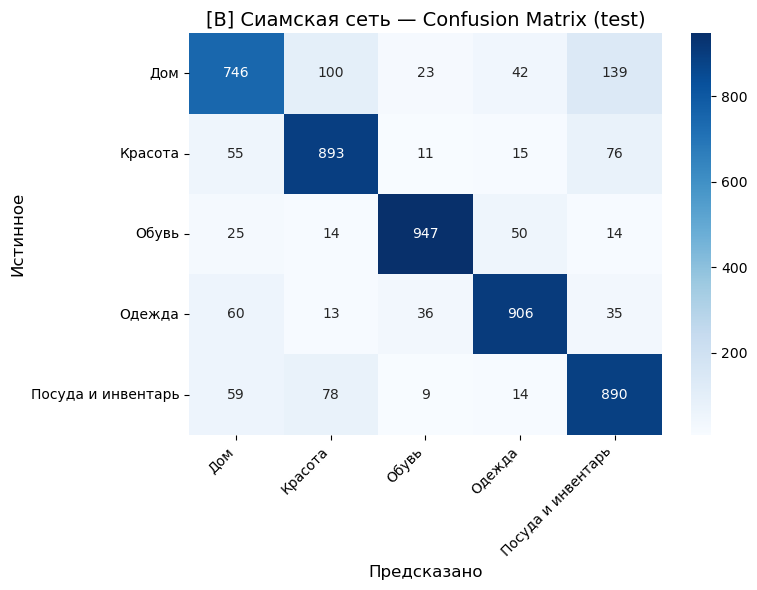

In [27]:
plot_confusion_matrix(y_test_enc, siam_test_pred, CLASS_NAMES,
                      title="[В] Сиамская сеть — Confusion Matrix (test)")

In [28]:
print("\n[В] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, siam_test_pred, le, texts_test, n=10)


[В] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Лоферы очень красивые и качественно сделаны,… Обувь                        Обувь                        yes
2   Отличное платье, трикотаж мягкий, не просвеч… Одежда                       Одежда                       yes
3   Крем супер, круглогодично пользуюсь только и… Красота                      Красота                      yes
4   Пришёл целый, это главное.Брал для офиса,кол… Дом                          Дом                          yes
5   У дочери кудрявые волосы, после шампуня было… Красота                      Красота                      yes
6   Это не спрей. Внутри густая кремообразная ма… Красота                      Красота                      yes
7   Отличные сапоги, мне и нужны были не сильно … Обувь  

### Диалог классификации — Метод В

In [29]:
dialog_log_siam = []

print("=" * 60)
print("[В] Диалог: классификация текста (Сиамская сеть + MiniLM)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

siamese.eval()
cat_t = torch.tensor(cat_emb_matrix, dtype=torch.float32).to(DEVICE)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb   = model_st.encode([user_input]).astype(np.float32)
    x_t   = torch.tensor(emb, dtype=torch.float32).to(DEVICE)
    x_rep = x_t.expand(len(CLASS_NAMES), -1)
    with torch.no_grad():
        scores = torch.sigmoid(siamese(x_rep, cat_t)).cpu().numpy()
    pred_enc = int(np.argmax(scores))
    pred_lbl = CLASS_NAMES[pred_enc]
    conf     = float(scores[pred_enc])
    print(f"  → Категория: {pred_lbl}  (score: {conf:.4f})\n")
    dialog_log_siam.append({'text': user_input, 'predicted': pred_lbl, 'score': conf})

if dialog_log_siam:
    with h5py.File('dialog_siamese_minilm.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',       data=np.asarray([d['text']      for d in dialog_log_siam], dtype=object), dtype=dt)
        f.create_dataset('predictions', data=np.asarray([d['predicted'] for d in dialog_log_siam], dtype=object), dtype=dt)
        f.create_dataset('scores',      data=np.array([d['score']       for d in dialog_log_siam]))
    print(f"Диалог сохранён: dialog_siamese_minilm.h5  ({len(dialog_log_siam)} запросов)")

[В] Диалог: классификация текста (Сиамская сеть + MiniLM)
Введите 'стоп' для выхода.
Доступные категории: ['Дом', 'Красота', 'Обувь', 'Одежда', 'Посуда и инвентарь']


Текст отзыва:  тарелки с рисунком. стеклянные и большие


  → Категория: Посуда и инвентарь  (score: 0.9958)



Текст отзыва:  для неспешных прогулок, на ногу садятся хорошо, швы прочные


  → Категория: Обувь  (score: 1.0000)



Текст отзыва:  отличные кроссовки для бега в сеточку на высокой подошве, качеством доволен, пришли быстро, спасибо


  → Категория: Обувь  (score: 1.0000)



Текст отзыва:  exit


Диалог сохранён: dialog_siamese_minilm.h5  (3 запросов)


### Файл 3 — Кеширование товарных эмбеддингов в пространстве Сиамской сети

Прогоняем `prod_X` (MiniLM-векторы товаров) через `siamese.encode()`.  
Результат — представление товаров в метрическом пространстве, обученном на задаче сопоставления отзывов с категориями.

**Почему это даёт другой результат, чем Файл 2:**  
Сиамский энкодер смещает пространство так, чтобы семантически близкие пары (отзыв ↔ категория) были ближе.  
Товары в этом пространстве кластеризуются иначе, чем в «сыром» MiniLM.  
Для MiniLM скрытое пространство энкодера имеет dim=256 (hidden), а не 384.

In [30]:
def project_through_encoder(model, X: np.ndarray, device: str, batch_size: int = 512) -> np.ndarray:
    """
    Прогоняет матрицу эмбеддингов X через siamese.encode().
    Возвращает проекцию в скрытое пространство сети (dim=hidden=256 для MiniLM).
    """
    model.eval()
    projected = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = torch.tensor(X[start:start + batch_size], dtype=torch.float32).to(device)
            projected.append(model.encode(batch).cpu().numpy())
    return np.vstack(projected)


if os.path.exists(CACHE_PRODUCTS_SIAM):
    print(f"[Файл 3] Кеш найден: {CACHE_PRODUCTS_SIAM} — загружаю...")
    with h5py.File(CACHE_PRODUCTS_SIAM, 'r') as f:
        prod_X_siam = f['X'][:]  # (N_prod, 256) — скрытое пространство MiniLM-энкодера
    print(f"[Файл 3] Загружено: {prod_X_siam.shape}")

else:
    print(f"[Файл 3] Кеш не найден — проецирую товары через сиамский энкодер...")
    prod_X_siam = project_through_encoder(siamese, prod_X, DEVICE)
    print(f"[Файл 3] Проекция готова: {prod_X_siam.shape}")

    print(f"[Файл 3] Сохраняю в {CACHE_PRODUCTS_SIAM} ...")
    with h5py.File(CACHE_PRODUCTS_SIAM, 'w') as f:
        # Сохраняем только эмбеддинги — метаданные уже есть в Файле 2
        f.create_dataset('X',      data=prod_X_siam, compression='gzip')
        f.create_dataset('nm_ids', data=prod_nm_ids)  # nm_ids для удобства автономного чтения
    print(f"[Файл 3] Сохранён: {CACHE_PRODUCTS_SIAM}")

print(f"\n[Файл 3] Индекс Siamese готов: {prod_X_siam.shape}  (товаров × hidden_dim)")

[Файл 3] Кеш найден: products_siamese_minilm.h5 — загружаю...
[Файл 3] Загружено: (785591, 256)

[Файл 3] Индекс Siamese готов: (785591, 256)  (товаров × hidden_dim)


### Поиск товаров — Метод В (Сиамская сеть)

**Индекс:** `products_siamese_minilm.h5` (Файл 3) — товары в пространстве сиамского энкодера (dim=256).  
**Запрос:** MiniLM → `siamese.encode()` → вектор в том же пространстве, что и товары из Файла 3.  
**Категория:** задаётся вручную (или `все`).  

Поскольку и запрос, и товары проецируются одним энкодером, косинусное расстояние отражает **метрику, обученную на задаче сопоставления**, а не просто языковую близость MiniLM.

In [31]:
search_log_siam = []
categories_str  = ', '.join(CLASS_NAMES)

print("=" * 70)
print("[В] Поиск товаров по запросу  (индекс: products_siamese_minilm.h5)")
print(f"Доступные категории: {categories_str}")
print("Введите 'стоп' в любом поле для выхода.")
print("=" * 70)

siamese.eval()

while True:
    query = input("\nЗапрос товара: ").strip()
    if query.lower() in ('стоп', 'stop', 'exit', 'quit', ''):
        break

    print(f"  Доступные категории: {categories_str}")
    print("  (или введите 'все' для поиска по всем категориям)")
    cat_input = input("  Категория: ").strip()
    if cat_input.lower() in ('стоп', 'stop', 'exit', 'quit'):
        break
    if cat_input.lower() != 'все' and cat_input not in CLASS_NAMES:
        print(f"  Категория '{cat_input}' не найдена. Доступны: {categories_str}")
        continue

    # Кодируем запрос: MiniLM → siamese.encode() → скрытое пространство (dim=256)
    raw_emb = model_st.encode([query]).astype(np.float32)
    with torch.no_grad():
        t         = torch.tensor(raw_emb, dtype=torch.float32).to(DEVICE)
        query_emb = siamese.encode(t).cpu().numpy()[0]  # dim=256, то же пространство, что Файл 3

    # Поиск в Файле 3: товары уже в том же пространстве
    results, elapsed = search_products(
        query_emb, cat_input,
        prod_X_siam,  # Файл 3: Siamese-эмбеддинги товаров
        prod_nm_ids, prod_categories, prod_ratings, prod_names, prod_descs
    )
    if results.empty:
        print(f"  Нет товаров в категории '{cat_input}'.")
        continue

    print_search_results(results, elapsed, cat_input)
    search_log_siam.append({'query': query, 'category': cat_input, 'elapsed_ms': elapsed * 1000})

save_search_log(search_log_siam, 'search_log_siamese_minilm.h5')

[В] Поиск товаров по запросу  (индекс: products_siamese_minilm.h5)
Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
Введите 'стоп' в любом поле для выхода.



Запрос товара:  зимняя куртка с мембраной непромокаемая


  Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
  (или введите 'все' для поиска по всем категориям)


  Категория:  все



  Время поиска по эмбеддингам: 1144.6 мс  |  Найдено: 10 товаров  Категория поиска: все
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [6563379] Платье-пиджак
      Рейтинг: 5.00 ★  |  Сходство: 0.3765
      Платье-пиджак двухбортное на подкладе из вискозы, выполнен из модной шотладской клетки. Приталенный силуэт, прорубные ка…

   2. [5014516] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.3744
      Платье из трикотажного полотна, украшено поясом и отделкой контрастного цвета.

   3. [9478496] Платье
      Рейтинг: 5.00 ★  |  Сходство: 0.3733
      Платье прямого силуэта выполнено из трикотажа. Детали: воротник-стойка, спущенная линия плеча, рукав 3/4, пояс в комплек…

   4. [9478495] Платье
      Рейтинг: 4.60 ★  |  Сходство: 0.3733
      Платье прямого силуэта выполнено из трикотажа. Детали: воротник-стойка, спущенная линия плеча, рукав 3/4, пояс в комплек…

   5. [12768469] Плащ
      Рейтинг: 5.00 ★  |  Сходство: 0.3725
      Сти

...

  Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
  (или введите 'все' для поиска по всем категориям)


  Категория:  все



  Время поиска по эмбеддингам: 1103.5 мс  |  Найдено: 10 товаров  Категория поиска: все
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [6070044] Конструктор из дерева (Танк МС-1)
      Рейтинг: 5.00 ★  |  Сходство: 0.4507
      **Танк деревянный с подвижным деталями МС-1 от "Армия России"** - легкий советский пехотный танк составлял основу советс…

   2. [6128165] Чайник из нержавеющей стали со свистком 3 л
      Рейтинг: 3.00 ★  |  Сходство: 0.4088
      Чайник MAYER & BOCH поможет быстро вскипятить воду, даже если у вас нет плиты. Посуда изготовлена из нержавеющей стали, …

   3. [6165528] Чайник
      Рейтинг: 2.67 ★  |  Сходство: 0.4085
      Чайник MAYER & BOCH поможет быстро вскипятить воду, даже если у вас нет плиты. Посуда изготовлена из нержавеющей стали, …

   4. [6629893] Нож перочинный  Pioneer,6 функций,алюминивая рукоять.
      Рейтинг: 4.50 ★  |  Сходство: 0.4068
      Перочинный нож PIONEER имеет 6 функций:большое лез


Запрос товара:  exit


  Лог поиска сохранён: search_log_siamese_minilm.h5  (4 запросов)


---
## Итоговое сравнение методов классификации

                     Метод   F1 val  F1 test
А: Логистическая регрессия 0.833697 0.835347
          В: Сиамская сеть 0.825431 0.834341
              Б: Центроиды 0.725219 0.721997


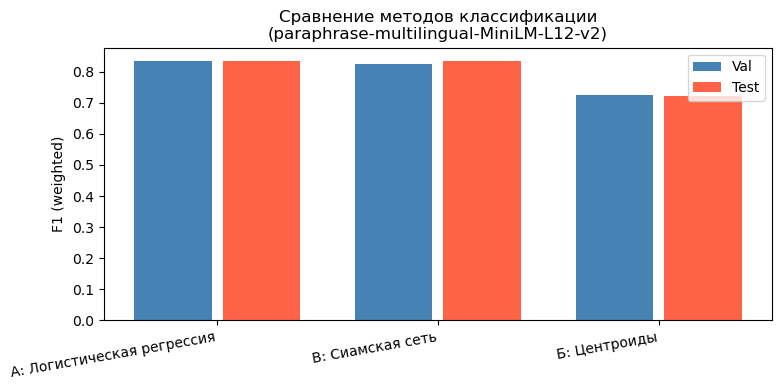

In [32]:
results_cmp = pd.DataFrame({
    'Метод':   ['А: Логистическая регрессия', 'Б: Центроиды', 'В: Сиамская сеть'],
    'F1 val':  [lr_f1_val,   cent_f1_val,  siam_f1_val],
    'F1 test': [lr_f1_test,  cent_f1_test, siam_f1_test],
})
results_cmp = results_cmp.sort_values('F1 test', ascending=False).reset_index(drop=True)
print(results_cmp.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results_cmp))
ax.bar(x - 0.2, results_cmp['F1 val'],  0.35, label='Val',  color='steelblue')
ax.bar(x + 0.2, results_cmp['F1 test'], 0.35, label='Test', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(results_cmp['Метод'], rotation=10, ha='right')
ax.set_ylabel('F1 (weighted)')
ax.set_title('Сравнение методов классификации\n(paraphrase-multilingual-MiniLM-L12-v2)')
ax.legend()
plt.tight_layout()
plt.show()